In [1]:
import pandas as pd

df = pd.read_csv('logbook_assignment1.csv')
df.head(10)

C:\Users\ndebe\AppData\Local\Temp\ipykernel_37640\3986919337.py:3: DtypeWarning: Columns (3,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('logbook_assignment1.csv')


,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...
5,Oct 23 2021,Oct 23 2021,"147,567",3.413,$3.739,$12.76,29.0,NaN,https://www.somewebsite.com/volkswagen/passat/...
6,Nov 20 2021,Dec 12 2021,"105,929",9.044,$4.639,$41.96,29.5,NaN,https://www.somewebsite.com/mazda/3_sport/2010...
7,Jan 20 2022,Jan 20 2022,"59,475",14.962,$2.929,$43.82,27.3,NaN,https://www.somewebsite.com/subaru/forester/20...
8,NaN,Apr 16 2018,"137,562",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/kianival/2009/789684
9,NaN,Nov 29 2020,"99,296",2.710,$1.999,$5.42,0.0,NaN,https://www.somewebsite.com/lexus/rx350/2012/8...


#  1 Data Cleaning

## 1.1 Date Fields

### Question 1: Percentage of invalid `date_fueled` entries
We attempt to parse `date_fueled` using the expected format (`%b %d %Y`, e.g. "Apr 7 2022"). 
Any value that doesn't match this format (e.g. free-text maintenance notes) is coerced to `NaT`.
We then compute what percentage of the column is `NaT`.

In [2]:
parsed = pd.to_datetime(df['date_fueled'], format='%b %d %Y', errors='coerce')
percent_invalid = parsed.isna().mean() * 100
print(percent_invalid)

11.678738924306518


### Question 2: Filling invalid `date_fueled` using `date_captured`
Where `date_fueled` could not be parsed but `date_captured` is a valid date, 
we use `date_captured` as a proxy for the fueling date, since it is likely close in time.

In [3]:
parsed_captured = pd.to_datetime(df['date_captured'], format='%b %d %Y', errors='coerce')

df['date_fueled_clean'] = parsed.copy()

mask = parsed.isna() & parsed_captured.notna()
df.loc[mask, 'date_fueled_clean'] = parsed_captured[mask]

print(f"Rows filled using date_captured: {mask.sum()}")

Rows filled using date_captured: 137210


### Question 3: Convert `date_fueled` to proper date format
`date_fueled_clean` was already converted to datetime type as part of the parsing 
in Questions 1–2, with invalid entries set to `NaT`. We confirm this below.


In [4]:
print(df['date_fueled_clean'].dtype)
print(df['date_fueled_clean'].isna().sum())

datetime64[ns]
0


### Question 4: Remove invalid date ranges
Some `date_fueled_clean` values may be in the future or earlier than 2005. We set these to `NaT`.

**Fix (confirmed with lecturer, 2 Sept 2026):** the brief's instruction to remove future/pre-2005 dates means the rest of the assignment continues on the dataset with these rows **dropped**, not just the date field nulled. Updated the cell below to drop them.

In [5]:
today = pd.Timestamp.today()

future_mask = df['date_fueled_clean'] > today
too_old_mask = df['date_fueled_clean'] < '2005-01-01'

print(f"Future dates: {future_mask.sum()}")
print(f"Dates before 2005: {too_old_mask.sum()}")

# FIX: drop these rows (not just null the date), per lecturer clarification
rows_before = len(df)
df = df.loc[~(future_mask | too_old_mask)].reset_index(drop=True)
print(f"Dropped {rows_before - len(df)} rows; {len(df)} rows remain")

Future dates: 12
Dates before 2005: 558
Dropped 570 rows; 1174300 rows remain


### Question 5: Distribution of fueling dates
We plot a histogram of `date_fueled_clean` to see how fill-up entries are 
distributed over time.

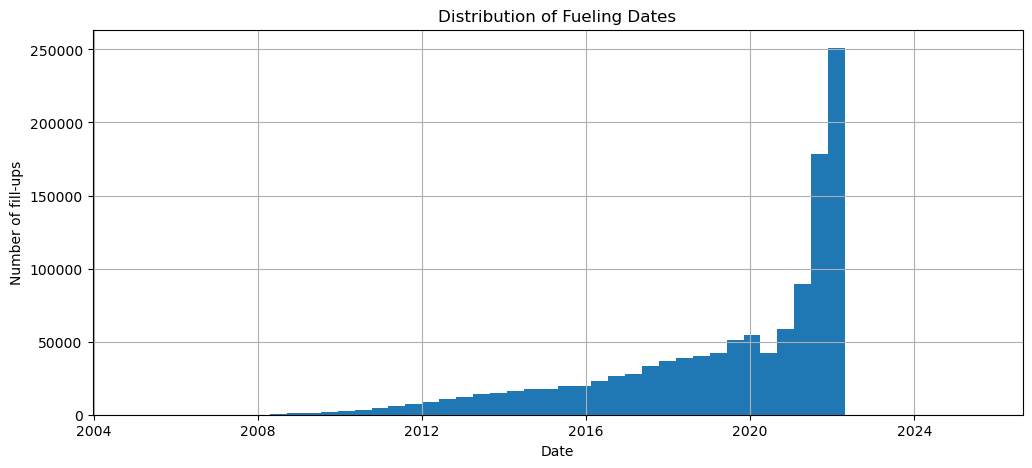

In [6]:
import matplotlib.pyplot as plt

df['date_fueled_clean'].hist(bins=50, figsize=(12, 5))
plt.xlabel('Date')
plt.ylabel('Number of fill-ups')
plt.title('Distribution of Fueling Dates')
plt.show()

## 1.2 Numeric Fields

### Question 1: Percentage of missing entries
We check what percentage of `gallons`, `miles`, and `odometer` are missing (NaN).

In [7]:
for col in ['gallons', 'miles', 'odometer']:
    pct_missing = df[col].isna().mean() * 100
    print(f"{col}: {pct_missing:.2f}% missing")

gallons: 6.32% missing
miles: 87.55% missing
odometer: 12.69% missing


### Question 3: Convert numeric fields to float
`gallons`, `miles`, `odometer`, and `mpg` are read in as text (object dtype), 
and some contain commas (thousands separators) or leading/trailing whitespace. We clean and convert these to proper float types so that Question 2 can work. 

In [8]:
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.strip().str.replace(',', '', regex=False),
        errors='coerce'
    )

df['gallons_clean'] = clean_numeric(df['gallons'])
df['miles_clean'] = clean_numeric(df['miles'])
df['odometer_clean'] = clean_numeric(df['odometer'])
df['mpg_clean'] = clean_numeric(df['mpg'])

df[['gallons', 'gallons_clean', 'miles', 'miles_clean', 'odometer', 'odometer_clean', 'mpg', 'mpg_clean']].head()

,gallons,gallons_clean,miles,miles_clean,odometer,odometer_clean,mpg,mpg_clean
0,NaN,NaN,NaN,NaN,"73,370",73370.0,NaN,NaN
1,12.120,12.120,NaN,NaN,"11,983",11983.0,31.6,31.6
2,7.991,7.991,NaN,NaN,"98,233",98233.0,28.5,28.5
3,10.575,10.575,NaN,NaN,"163,802",163802.0,46.8,46.8
4,11.651,11.651,244.4,244.4,NaN,NaN,21.0,21.0


### Fix: `mpg == 0` with `gallons > 0` must be treated as missing
Confirmed with the lecturer (2 Sept 2026): a vehicle can't register fuel efficiency while consuming fuel and travelling 0 miles, so these are missing readings, not real ones. This has to happen **before** the miles/gallons/mpg backfill in the next cell — otherwise `miles = mpg(=0) * gallons` silently writes a false `miles = 0` for every affected row, which then contaminates `km_driven` and any stat built on it downstream (only the resulting `inf` in `litres_per_100km` was being caught later; the false zeros in `miles_clean`/`km_driven` themselves were not).

In [9]:
import numpy as np

mpg_zero_bad = (df['mpg_clean'] == 0) & (df['gallons_clean'] > 0)
print(f"Rows with mpg==0 and gallons>0 (treated as missing): {mpg_zero_bad.sum()}")
df.loc[mpg_zero_bad, 'mpg_clean'] = np.nan

Rows with mpg==0 and gallons>0 (treated as missing): 138496


### Question 2: Filling missing values
We use the relationship `miles = mpg × gallons` to fill in missing values.

In [10]:
mask = df['miles_clean'].isna() & df['mpg_clean'].notna() & df['gallons_clean'].notna()
df.loc[mask, 'miles_clean'] = df.loc[mask, 'mpg_clean'] * df.loc[mask, 'gallons_clean']

mask_gallons = df['gallons_clean'].isna() & df['miles_clean'].notna() & df['mpg_clean'].notna()
df.loc[mask_gallons, 'gallons_clean'] = df.loc[mask_gallons, 'miles_clean'] / df.loc[mask_gallons, 'mpg_clean']

mask_mpg = df['mpg_clean'].isna() & df['miles_clean'].notna() & df['gallons_clean'].notna()
df.loc[mask_mpg, 'mpg_clean'] = df.loc[mask_mpg, 'miles_clean'] / df.loc[mask_mpg, 'gallons_clean']

print(f"Miles filled: {mask.sum()}")
print(f"Gallons filled: {mask_gallons.sum()}")
print(f"MPG filled: {mask_mpg.sum()}")

Miles filled: 819791
Gallons filled: 0
MPG filled: 4315


In [11]:
print(df[['miles_clean', 'gallons_clean', 'mpg_clean']].isna().sum())

miles_clean      208352
gallons_clean     74171
mpg_clean        208352
dtype: int64


### Question 4: Distributions of numeric fields
We plot histograms of `gallons_clean`, `miles_clean`, `odometer_clean`, and `mpg_clean`.

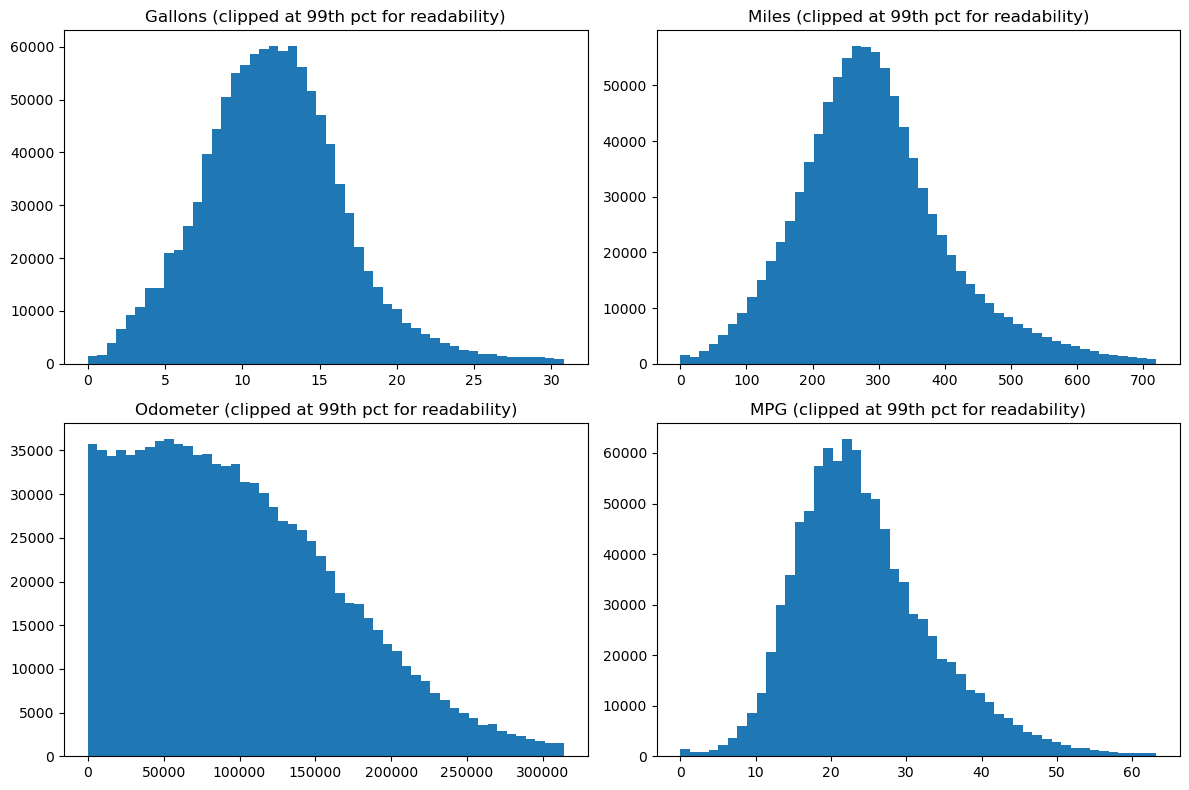

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# FIX: clip each column's display range to its own 99th percentile before plotting.
# A handful of physically-impossible extreme values (e.g. an odometer reading in
# the hundreds of millions) otherwise stretch the x-axis so far that every real,
# in-range data point gets crushed into a single bar at 0 - the histogram doesn't
# show the actual shape of the distribution at all. This only changes what's
# DISPLAYED, not the underlying data - df itself is untouched.
plot_cols = [
    ('gallons_clean', 'Gallons', axes[0, 0]),
    ('miles_clean', 'Miles', axes[0, 1]),
    ('odometer_clean', 'Odometer', axes[1, 0]),
    ('mpg_clean', 'MPG', axes[1, 1]),
]
for col, title, ax in plot_cols:
    clip_hi = df[col].quantile(0.99)
    data = df[col].dropna()
    data = data[(data >= 0) & (data <= clip_hi)]
    ax.hist(data, bins=50)
    ax.set_title(f"{title} (clipped at 99th pct for readability)")

plt.tight_layout()
plt.show()

### Question 5: Statistical description of numeric columns
Summary statistics for `gallons_clean`, `miles_clean`, `odometer_clean`, and `mpg_clean`.

In [13]:
cols = ['gallons_clean', 'miles_clean', 'odometer_clean', 'mpg_clean']

desc = df[cols].describe()
mode_row = df[cols].mode().iloc[0]
desc.loc['mode'] = mode_row

print(desc)

       gallons_clean    miles_clean  odometer_clean      mpg_clean
count   1.100129e+06  965948.000000    1.025263e+06  965948.000000
mean    1.279743e+01     306.883953    1.040011e+05      26.919453
std     7.448279e+01     767.082116    3.405976e+05     604.779833
min     0.000000e+00       0.000000    0.000000e+00       0.000000
25%     8.990000e+00     219.186600    4.592400e+04      18.200000
50%     1.195400e+01     283.869450    9.188800e+04      23.300000
75%     1.493900e+01     355.391400    1.469255e+05      29.800000
max     2.838000e+04  195321.200000    2.543621e+08  559860.946746
mode    1.056700e+01       0.000000    1.000000e+00      21.000000


# 2 Feature Engineering

## Creating New Features

### Question 1: Extract currency
Before extracting currency values, we first inspect `cost_per_gallon` to understand 
what currency symbols actually appear in the raw data.

In [14]:
import re

sample = df['cost_per_gallon'].dropna().astype(str)
prefixes = sample.str.extract(r'^([^\d]+)')[0].value_counts()
print(prefixes.head(30))

0
$      739584
£       86391
€       58500
CA$     46351
R       36118
AU$     23184
RM       8572
NZ$      7543
R$       6307
zł       5283
Skr      4897
Rs       4737
₱        4176
฿        4132
Ft       3782
Dkr      3780
RUB      3732
MXN      3280
Nkr      2978
BGN      2852
S$       2628
Kč       2365
RON      2072
₪        1820
₩        1727
HK$      1621
NT$      1597
kn       1415
Fr.      1381
AR$      1286
Name: count, dtype: int64


### Question 1: Create currency column
We extract the currency symbol/code as all non-digit characters at the start of 
`cost_per_gallon`. We use `cost_per_gallon` rather than `total_spent` since both 
should carry the same currency, but this could equally be validated against both.

In [15]:
df['currency'] = df['cost_per_gallon'].dropna().astype(str).str.extract(r'^([^\d]+)')[0]

print(df['currency'].value_counts())

currency
$      739584
£       86391
€       58500
CA$     46351
R       36118
        ...  
CV$        11
KGS         9
L$          9
IQD         8
YR          4
Name: count, Length: 121, dtype: int64


In [16]:
print(df['currency'].unique())

[nan '$' '£' 'RON' '€' 'zł' 'AU$' '₩' 'Ft' 'NZ$' 'Nkr' 'R$' 'CA$' 'RUB'
 '₪' 'Rp' 'RM' 'R' 'Skr' 'AR$' 'TL' 'din.' 'Ikr' '฿' 'CN¥' 'HK$' 'Dkr' '₡'
 '₴' 'IRR' 'S$' 'Rs' 'BGN' '¥' 'AED' 'MKD' '₱' 'BD' 'CL$' 'EC$' '$U' 'LE'
 'MXN' 'CO$' 'CFPF' 'Kč' 'kn' 'JD' 'FCFA' 'NT$' 'BN$' 'RD$' 'S/.' 'J$'
 'PKRs' 'Ksh' 'GY$' 'KM' 'Fr.' 'CFA' 'MDL' 'MMK' 'N$' '₦' 'ZWL' 'USh'
 'MURs' 'BYN' 'TT$' 'KD' 'B/.' 'Bs.F.' 'SLRs' 'SR' 'GTQ' 'QR' 'Br' 'C$'
 'BWP' 'GH₵' 'Tk' 'SR$' 'man.' 'KHR' 'BZ$' 'Bds$' 'Kz' 'NPRs' 'OMR' '₲'
 'LB£' 'HNL' 'AMD' 'GEL' '₮' 'MTn' 'ZMW' 'SH£' '₫' 'RWF' 'MGA' 'DT' 'VT'
 'MOP$' 'TMT' 'SY£' 'BS$' 'Af' 'ALL' 'DA' 'TSh' 'KY$' 'Bs' 'NAf.' 'KZT'
 'YR' 'MAD' 'CV$' 'IQD' 'CU$' 'KGS' 'L$']


In [17]:
print(len(df))
print(df['currency'].isna().sum())
print(df['cost_per_gallon'].isna().sum())

1174300
80719
80719


In [18]:
df[['cost_per_gallon', 'currency']].head(10)

,cost_per_gallon,currency
0,NaN,NaN
1,$5.599,$
2,£5.45,£
3,£5.11,£
4,$3.029,$
5,$3.739,$
6,$4.639,$
7,$2.929,$
8,NaN,NaN
9,$1.999,$


In [19]:
df.head()

,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url,date_fueled_clean,gallons_clean,miles_clean,odometer_clean,mpg_clean,currency
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...,2022-04-07,NaN,NaN,73370.0,NaN,NaN
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150,2012-11-07,12.120,382.9920,11983.0,31.6,$
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...,2012-09-22,7.991,227.7435,98233.0,28.5,£
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233,2019-05-04,10.575,494.9100,163802.0,46.8,£
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...,2022-02-15,11.651,244.4000,NaN,21.0,$


### Question 2: Extract numeric value from cost fields
We extract the numeric portion of `cost_per_gallon` and `total_spent`.

In [20]:
import numpy as np

def extract_amount(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'\d[\d.,]*', str(value))
    if not match:
        return np.nan
    number_str = match.group().replace(',', '')
    return float(number_str)

test_values = ['$5.599', 'RON16.69', 'Fr.1381', '£43.53', 'din.500']
for v in test_values:
    print(v, '->', extract_amount(v))

df['cost_per_gallon_value'] = df['cost_per_gallon'].apply(extract_amount)
df['total_spent_value'] = df['total_spent'].apply(extract_amount)

df[['cost_per_gallon', 'cost_per_gallon_value', 'total_spent', 'total_spent_value']].head(10)

$5.599 -> 5.599
RON16.69 -> 16.69
Fr.1381 -> 1381.0
£43.53 -> 43.53
din.500 -> 500.0


,cost_per_gallon,cost_per_gallon_value,total_spent,total_spent_value
0,NaN,NaN,NaN,NaN
1,$5.599,5.599,$67.86,67.86
2,£5.45,5.450,£43.53,43.53
3,£5.11,5.110,£54.00,54.00
4,$3.029,3.029,$35.29,35.29
5,$3.739,3.739,$12.76,12.76
6,$4.639,4.639,$41.96,41.96
7,$2.929,2.929,$43.82,43.82
8,NaN,NaN,NaN,NaN
9,$1.999,1.999,$5.42,5.42


### Question 3: Extract make, model, year, and user ID from URL
We split `user_url` on `/` and extract the last four segments, which consistently represent `make`, `model`, `year`, and `user_id` in that order. Indexing from the end of the list rather than the start, because the URL prefix length is consistent 
but not always the segment count (e.g. cases where make and model are merged, such as "kianival").

In [21]:
url_parts = df['user_url'].str.rstrip('/').str.split('/')
url_parts.head(10)

0    [https:, , www.somewebsite.com, suzuki, swift,...
1    [https:, , www.somewebsite.com, bmw, x3, 2009,...
2    [https:, , www.somewebsite.com, mercedes-benz,...
3    [https:, , www.somewebsite.com, bmw, 320d, 201...
4    [https:, , www.somewebsite.com, honda, passpor...
5    [https:, , www.somewebsite.com, volkswagen, pa...
6    [https:, , www.somewebsite.com, mazda, 3_sport...
7    [https:, , www.somewebsite.com, subaru, forest...
8    [https:, , www.somewebsite.com, kianival, 2009...
9    [https:, , www.somewebsite.com, lexus, rx350, ...
Name: user_url, dtype: object

In [22]:
url_parts = df['user_url'].str.rstrip('/').str.split('/')

df['make'] = url_parts.str[-4]
df['model'] = url_parts.str[-3]
df['year'] = url_parts.str[-2]
df['user_id'] = url_parts.str[-1]

df[['user_url', 'make', 'model', 'year', 'user_id']].head(10)

,user_url,make,model,year,user_id
0,https://www.somewebsite.com/suzuki/swift/2015/...,suzuki,swift,2015,674857
1,https://www.somewebsite.com/bmw/x3/2009/461150,bmw,x3,2009,461150
2,https://www.somewebsite.com/mercedes-benz/e300...,mercedes-benz,e300,1998,133501
3,https://www.somewebsite.com/bmw/320d/2010/247233,bmw,320d,2010,247233
4,https://www.somewebsite.com/honda/passport/201...,honda,passport,2019,1038865
5,https://www.somewebsite.com/volkswagen/passat/...,volkswagen,passat,2004,445811
6,https://www.somewebsite.com/mazda/3_sport/2010...,mazda,3_sport,2010,529810
7,https://www.somewebsite.com/subaru/forester/20...,subaru,forester,2020,1087864
8,https://www.somewebsite.com/kianival/2009/789684,www.somewebsite.com,kianival,2009,789684
9,https://www.somewebsite.com/lexus/rx350/2012/8...,lexus,rx350,2012,898688


### Question 3 (revised): Handle URLs with merged make/model
Some URLs have only 6 segments instead of 7 (e.g. "kianival" instead of separate "kia"/"nival"), meaning make and model were not separated at the source. For these rows, we mark `make` as missing and keep the merged string as `model`, rather than guessing the split.

In [23]:
url_parts = df['user_url'].str.rstrip('/').str.split('/')
num_parts = url_parts.str.len()

df['year'] = url_parts.str[-2]
df['user_id'] = url_parts.str[-1]

# Normal case: 7 parts, make and model are separate
normal_mask = num_parts == 7
df.loc[normal_mask, 'make'] = url_parts[normal_mask].str[-4]
df.loc[normal_mask, 'model'] = url_parts[normal_mask].str[-3]

# Short case: 6 parts, make/model merged - mark make as missing
short_mask = num_parts == 6
df.loc[short_mask, 'make'] = np.nan
df.loc[short_mask, 'model'] = url_parts[short_mask].str[-3]

print(f"Normal URLs (make/model separate): {normal_mask.sum()}")
print(f"Short URLs (make/model merged): {short_mask.sum()}")
print(f"Other lengths (unexpected): {(~normal_mask & ~short_mask).sum()}")

df[['user_url', 'make', 'model', 'year', 'user_id']].head(10)

Normal URLs (make/model separate): 1169238
Short URLs (make/model merged): 4732
Other lengths (unexpected): 330


,user_url,make,model,year,user_id
0,https://www.somewebsite.com/suzuki/swift/2015/...,suzuki,swift,2015,674857
1,https://www.somewebsite.com/bmw/x3/2009/461150,bmw,x3,2009,461150
2,https://www.somewebsite.com/mercedes-benz/e300...,mercedes-benz,e300,1998,133501
3,https://www.somewebsite.com/bmw/320d/2010/247233,bmw,320d,2010,247233
4,https://www.somewebsite.com/honda/passport/201...,honda,passport,2019,1038865
5,https://www.somewebsite.com/volkswagen/passat/...,volkswagen,passat,2004,445811
6,https://www.somewebsite.com/mazda/3_sport/2010...,mazda,3_sport,2010,529810
7,https://www.somewebsite.com/subaru/forester/20...,subaru,forester,2020,1087864
8,https://www.somewebsite.com/kianival/2009/789684,NaN,kianival,2009,789684
9,https://www.somewebsite.com/lexus/rx350/2012/8...,lexus,rx350,2012,898688


In [24]:
df.head()

,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url,date_fueled_clean,...,miles_clean,odometer_clean,mpg_clean,currency,cost_per_gallon_value,total_spent_value,make,model,year,user_id
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...,2022-04-07,...,NaN,73370.0,NaN,NaN,NaN,NaN,suzuki,swift,2015,674857
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150,2012-11-07,...,382.9920,11983.0,31.6,$,5.599,67.86,bmw,x3,2009,461150
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...,2012-09-22,...,227.7435,98233.0,28.5,£,5.450,43.53,mercedes-benz,e300,1998,133501
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233,2019-05-04,...,494.9100,163802.0,46.8,£,5.110,54.00,bmw,320d,2010,247233
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...,2022-02-15,...,244.4000,NaN,21.0,$,3.029,35.29,honda,passport,2019,1038865


## Proper Measurement Standards

### Question 1: Feature: litres_filled
We convert `gallons_clean` to litres. Since gallon size differs by country (US gallon = 3.785 L, UK/Imperial gallon = 4.546 L), we use the `currency` column as a proxy to decide which conversion to apply — currencies associated with UK-gallon-using countries (e.g. `£`) use the Imperial conversion; all others default to the US gallon.

In [25]:
US_GALLON_TO_LITRES = 3.78541
UK_GALLON_TO_LITRES = 4.54609

# Currencies from countries that use UK/Imperial gallons
uk_gallon_currencies = ['£']

df['litres_filled'] = df['gallons_clean'] * US_GALLON_TO_LITRES
df.loc[df['currency'].isin(uk_gallon_currencies), 'litres_filled'] = (
    df.loc[df['currency'].isin(uk_gallon_currencies), 'gallons_clean'] * UK_GALLON_TO_LITRES
)

df[['gallons_clean', 'currency', 'litres_filled']].head(10)

,gallons_clean,currency,litres_filled
0,NaN,NaN,NaN
1,12.120,$,45.879169
2,7.991,£,36.327805
3,10.575,£,48.074902
4,11.651,$,44.103812
5,3.413,$,12.919604
6,9.044,$,34.235248
7,14.962,$,56.637304
8,NaN,NaN,NaN
9,2.710,$,10.258461


### Question 2 km_driven and litres_per_100km
We convert `miles_clean` to kilometres using the standard conversion factor, then compute fuel efficiency in litres per 100km using `litres_filled` and `km_driven`.

In [26]:
miles_to_km = 1.609344

df['km_driven'] = df['miles_clean'] * miles_to_km
df['litres_per_100km'] = df['litres_filled'] / (df['km_driven'] / 100)

df[['miles_clean', 'km_driven', 'gallons_clean', 'litres_filled', 'litres_per_100km']].head(10)

,miles_clean,km_driven,gallons_clean,litres_filled,litres_per_100km
0,NaN,NaN,NaN,NaN,NaN
1,382.9920,616.365877,12.120,45.879169,7.443496
2,227.7435,366.517635,7.991,36.327805,9.911612
3,494.9100,796.480439,10.575,48.074902,6.035917
4,244.4000,393.323674,11.651,44.103812,11.213109
5,98.9770,159.288041,3.413,12.919604,8.110844
6,266.7980,429.369761,9.044,34.235248,7.973372
7,408.4626,657.356835,14.962,56.637304,8.615915
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,2.710,10.258461,NaN


In [27]:
inf_count = np.isinf(df['litres_per_100km']).sum()
print(f"Infinite litres_per_100km values: {inf_count}")

Infinite litres_per_100km values: 0


### Handling infinite litres_per_100km values
Rows where `miles_clean` is 0 produce an infinite `litres_per_100km` value (division by zero), which is not a meaningful measurement. We convert these to `NaN` rather than leaving them as `inf`, since `inf` would distort any later statistics, plots, or outlier-detection logic.

In [28]:
inf_mask = np.isinf(df['litres_per_100km'])
df.loc[inf_mask, 'litres_per_100km'] = np.nan

print(f"Remaining infinite values: {np.isinf(df['litres_per_100km']).sum()}")
print(f"Missing litres_per_100km: {df['litres_per_100km'].isna().sum()}")

Remaining infinite values: 0
Missing litres_per_100km: 208921


In [29]:
df.head()

,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url,date_fueled_clean,...,currency,cost_per_gallon_value,total_spent_value,make,model,year,user_id,litres_filled,km_driven,litres_per_100km
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...,2022-04-07,...,NaN,NaN,NaN,suzuki,swift,2015,674857,NaN,NaN,NaN
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150,2012-11-07,...,$,5.599,67.86,bmw,x3,2009,461150,45.879169,616.365877,7.443496
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...,2012-09-22,...,£,5.450,43.53,mercedes-benz,e300,1998,133501,36.327805,366.517635,9.911612
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233,2019-05-04,...,£,5.110,54.00,bmw,320d,2010,247233,48.074902,796.480439,6.035917
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...,2022-02-15,...,$,3.029,35.29,honda,passport,2019,1038865,44.103812,393.323674,11.213109


---
# 3 Vehicle Exploration (Person B)

Per the brief, this section looks at the global population **before** outlier
removal, so it runs directly on Person A's `df` (post-cleaning,
post-feature-engineering), not on any outlier-filtered version.

In [30]:
CURRENCY_TO_COUNTRY = {
    "$": "USA", "£": "UK", "€": "Eurozone", "CA$": "Canada", "R": "South Africa",
    "AU$": "Australia", "RM": "Malaysia", "NZ$": "New Zealand", "R$": "Brazil",
    "zł": "Poland", "Skr": "Sweden", "Rs": "India/Pakistan", "Ft": "Hungary",
    "Dkr": "Denmark", "RUB": "Russia", "MXN": "Mexico", "Nkr": "Norway",
    "S$": "Singapore", "Kč": "Czechia", "RON": "Romania", "HK$": "Hong Kong",
    "Fr.": "Switzerland",
}
df["country"] = df["currency"].map(CURRENCY_TO_COUNTRY).fillna("Other")


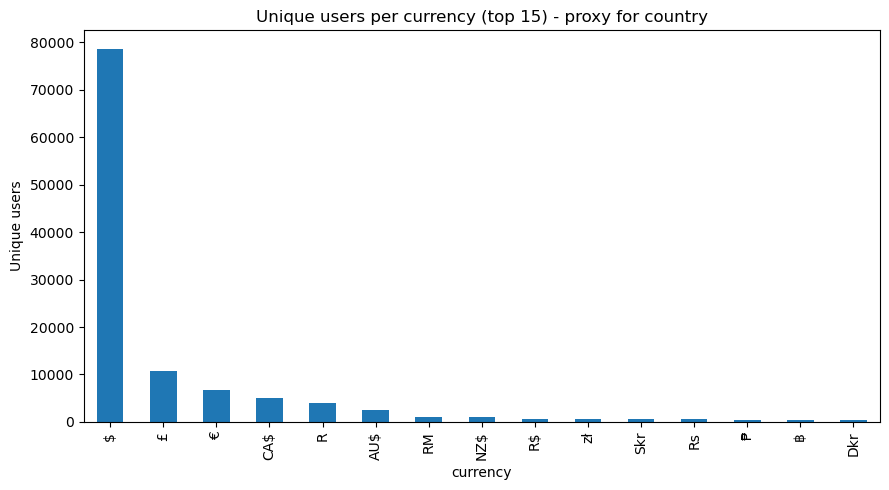

currency
$      78560
£      10767
€       6717
CA$     5045
R       4019
AU$     2586
RM       990
NZ$      980
R$       700
zł       568
Skr      560
Rs       533
₱        479
฿        443
Dkr      423
Name: user_id, dtype: int64

In [31]:
## Q3.1 - unique users per currency (proxy for country)
users_per_currency = df.groupby("currency")["user_id"].nunique().sort_values(ascending=False)
top15_cur = users_per_currency.head(15)
fig, ax = plt.subplots(figsize=(9, 5))
top15_cur.plot(kind="bar", ax=ax)
ax.set_title("Unique users per currency (top 15) - proxy for country")
ax.set_ylabel("Unique users")
plt.tight_layout()
plt.show()
top15_cur


**Note:** `currency` is only populated where `cost_per_gallon` itself was
present (Person A's Q2.1 choice, not changed here) - so this slightly
undercounts users whose `cost_per_gallon` was missing but `total_spent` would
have revealed their currency. Small effect on this ranking, not touched since
it's Person A's feature and not part of Person B's scope.

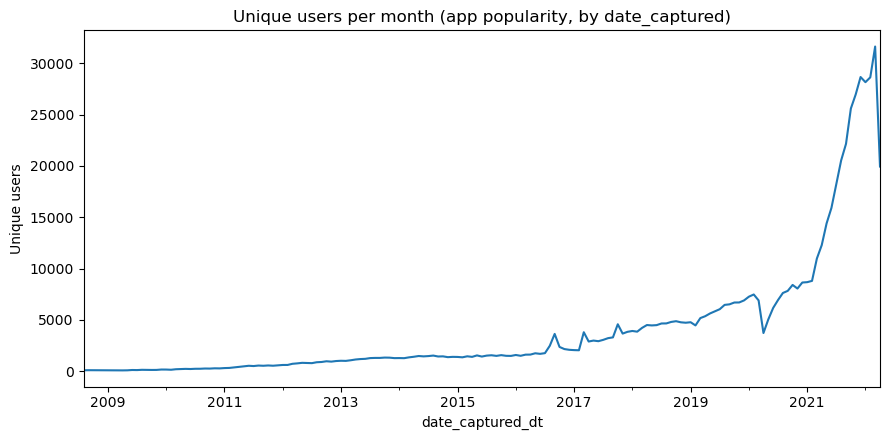

Peak month: 2022-03 with 31623 unique users


In [32]:
## Q3.2 - unique users per day (popularity of the app), by date_captured
df["date_captured_dt"] = pd.to_datetime(df["date_captured"], format="%b %d %Y", errors="coerce")
users_per_month = df.groupby(df["date_captured_dt"].dt.to_period("M"))["user_id"].nunique()
fig, ax = plt.subplots(figsize=(9, 4.5))
users_per_month.plot(ax=ax)
ax.set_title("Unique users per month (app popularity, by date_captured)")
ax.set_ylabel("Unique users")
plt.tight_layout()
plt.show()
print("Peak month:", users_per_month.idxmax(), "with", users_per_month.max(), "unique users")


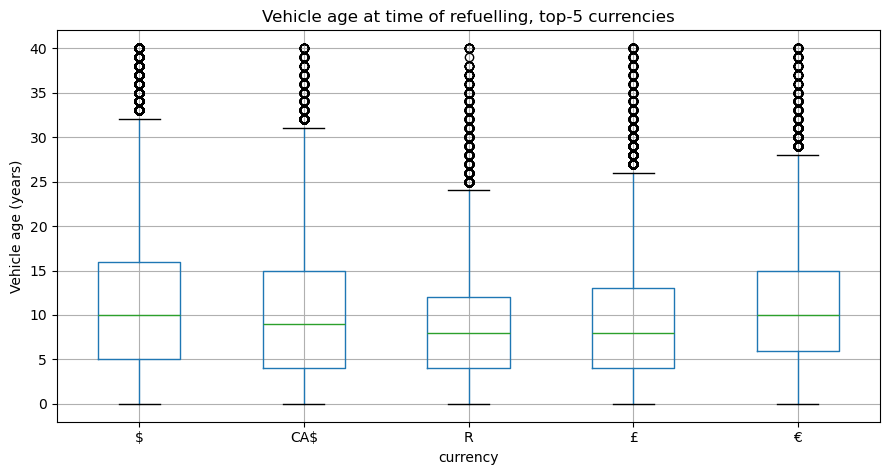

currency
$      10.0
CA$     9.0
R       8.0
£       8.0
€      10.0
Name: vehicle_age, dtype: float64

In [33]:
## Q3.3 - vehicle age distribution per country (age at time of refuelling,
## NOT the current date - uses date_fueled_clean, not today())
df["vehicle_year_num"] = pd.to_numeric(df["year"], errors="coerce")
df["vehicle_age"] = df["date_fueled_clean"].dt.year - df["vehicle_year_num"]

top5_currencies_by_users = users_per_currency.head(5).index.tolist()
plot_df = df[df["currency"].isin(top5_currencies_by_users) & df["vehicle_age"].between(0, 40)]
fig, ax = plt.subplots(figsize=(9, 5))
plot_df.boxplot(column="vehicle_age", by="currency", ax=ax)
ax.set_title("Vehicle age at time of refuelling, top-5 currencies")
ax.set_ylabel("Vehicle age (years)")
plt.suptitle("")
plt.tight_layout()
plt.show()
plot_df.groupby("currency")["vehicle_age"].median()


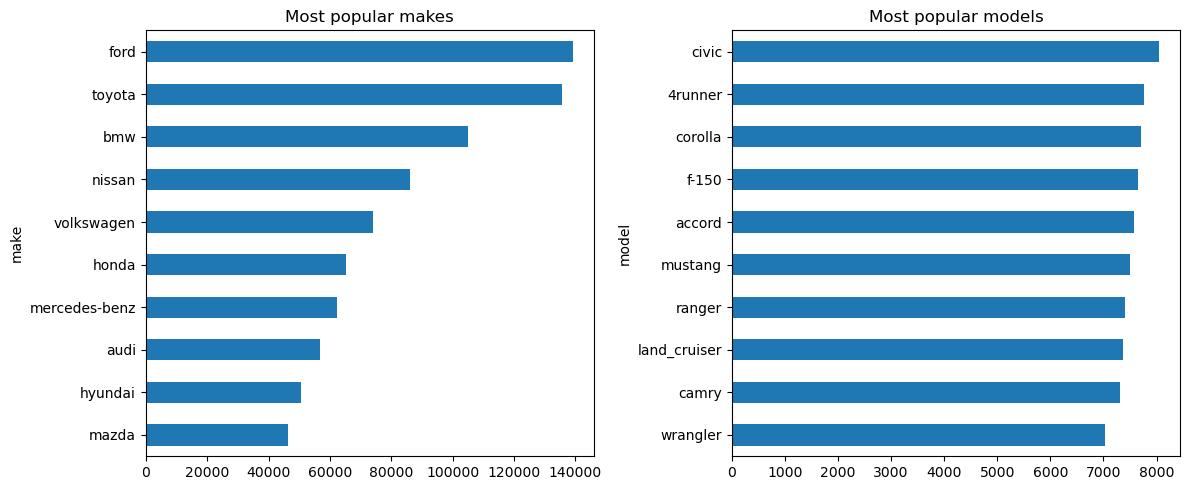

make
ford             139035
toyota           135765
bmw              105142
nissan            86219
volkswagen        74020
honda             65115
mercedes-benz     62273
audi              56728
hyundai           50655
mazda             46218
Name: count, dtype: int64
model
civic           8040
4runner         7761
corolla         7706
f-150           7645
accord          7583
mustang         7506
ranger          7405
land_cruiser    7374
camry           7316
wrangler        7023
Name: count, dtype: int64


In [34]:
## Q3.4 - most popular makes and models
top_makes = df["make"].value_counts().head(10)
top_models = df["model"].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_makes.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Most popular makes")
top_models.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Most popular models")
plt.tight_layout()
plt.show()
print(top_makes)
print(top_models)


**Discussion (Section 3):** Ford, Toyota and BMW dominate by raw count,
consistent with the dataset's USD/GBP skew. Mainstream commuter/work vehicles
top the model list (Civic, Corolla, F-150, Accord, etc.) - a sensible
reflection of a general logbook-app population.

---
# 4 Fuel Usage (Person B: 4.1 Outliers, then 4.3 SA Prices)

Section 4.2 (Fuel Efficiency) is Person C's part and is intentionally not
included here.

## 4.1 Outlier Removal

**Method and reasoning.** We remove outliers *per currency*, using
**1st-99th percentile clipping** on four signal columns: `total_spent_value`,
`litres_filled`, `cost_per_litre` (computed below), and `gallons_clean`. This
follows Lecture 2's outlier-methods overview:
- Z-score/std-dev clipping assumes roughly-normal data; these fields are
  heavily right-skewed (see Section 1.2's histograms), so z-score bounds
  would themselves be distorted by the outliers we're trying to remove.
- Percentile clipping is scale-free and **currency-agnostic** - it needs no
  prior "normal" price band for each of the top-5 currencies; it derives that
  band from each currency's own distribution.
- This directly targets the brief's flagged failure mode: an SA user whose
  currency is mislabelled as `$` will show Rand-sized totals against a
  population of genuine-USD rows, landing in that population's extreme
  percentiles and getting removed.
- We check total spend, litres **and** cost-per-litre (not just one), since a
  single corrupted field can still produce a plausible reading in isolation
  while implying a nonsensical combination overall.

In [35]:
## cost_per_litre, needed for outlier detection (not created by Person A)
df["cost_per_litre"] = df["total_spent_value"] / df["litres_filled"]
df["cost_per_litre"] = df["cost_per_litre"].replace([np.inf, -np.inf], np.nan)


In [36]:
## Q4.1.1 - top 5 currencies by NUMBER OF TRANSACTIONS (distinct from Section 3,
## which ranked by unique users - here it happens to give the same top 5)
txn_counts = df["currency"].value_counts()
top5_currencies = txn_counts.head(5).index.tolist()
print("Top 5 currencies by transaction count:", txn_counts.head(5).to_dict())


Top 5 currencies by transaction count: {'$': 739584, '£': 86391, '€': 58500, 'CA$': 46351, 'R': 36118}


In [37]:
## Q4.1.2 - per-currency outlier removal
LOWER_Q, UPPER_Q = 0.01, 0.99
SIGNAL_COLS = ["total_spent_value", "litres_filled", "cost_per_litre", "gallons_clean"]

keep_mask = pd.Series(True, index=df.index)
for cur in top5_currencies:
    cur_idx = df.index[df["currency"] == cur]
    cur_keep = pd.Series(True, index=cur_idx)
    for col in SIGNAL_COLS:
        vals = df.loc[cur_idx, col]
        lo, hi = vals.quantile(LOWER_Q), vals.quantile(UPPER_Q)
        col_ok = vals.between(lo, hi) | vals.isna()
        cur_keep &= col_ok
    keep_mask.loc[cur_idx] = cur_keep

df_top5_before = df[df["currency"].isin(top5_currencies)]
n_removed = int((~keep_mask.loc[df_top5_before.index]).sum())
print(f"Removed {n_removed} / {len(df_top5_before)} rows ({100*n_removed/len(df_top5_before):.2f}%) from the top-5-currency subset")

df_stage2 = df.loc[keep_mask].copy()
df_stage2["in_top5_clean"] = df_stage2["currency"].isin(top5_currencies)


Removed 36882 / 966944 rows (3.81%) from the top-5-currency subset


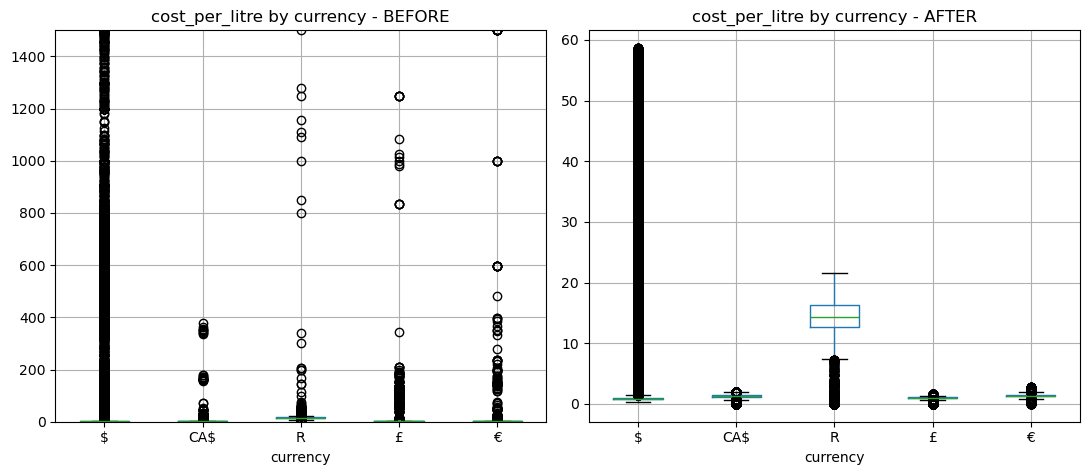

In [38]:
## Q4.1.3 - how many values were removed
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
before_plot = df[df["currency"].isin(top5_currencies)]
before_plot.boxplot(column="cost_per_litre", by="currency", ax=axes[0])
axes[0].set_title("cost_per_litre by currency - BEFORE")
axes[0].set_ylim(0, before_plot["cost_per_litre"].quantile(0.999))
after_plot = df_stage2[df_stage2["currency"].isin(top5_currencies)]
after_plot.boxplot(column="cost_per_litre", by="currency", ax=axes[1])
axes[1].set_title("cost_per_litre by currency - AFTER")
plt.suptitle("")
plt.tight_layout()
plt.show()


**Discussion (4.1.3):** the removed fraction (printed above) should sit well
within the lecturer-confirmed norm that removing 10-20% during cleaning is
acceptable - the percentile method here is deliberately conservative, only
stripping the most extreme 1% at each tail, per column, per currency. The
before/after boxplots show a visibly tighter, more currency-plausible
`cost_per_litre` band after removal.

---
# 4.2 Fuel Efficiency (Person C)

This section continues directly from Person B's 4.1 Outlier Removal, using
`df_stage2` (Person A's cleaned + feature-engineered data, run through Person
B's per-currency 1st-99th percentile outlier removal) and the `top5_currencies`
list from 4.1.1. Per the brief, outlier removal was only performed on the
top-5-currency subset, so all fuel-efficiency analysis here is restricted to
that subset via the `in_top5_clean` flag Person B added.

In [39]:
df42 = df_stage2[df_stage2["in_top5_clean"]].copy()
print(f"Rows in top-5-currency, outlier-cleaned subset used for 4.2: {len(df42)}")
print("Top 5 currencies:", top5_currencies)
df42[["currency", "country", "make", "model", "vehicle_age", "km_driven", "litres_per_100km"]].head()


Rows in top-5-currency, outlier-cleaned subset used for 4.2: 930062
Top 5 currencies: ['$', '£', '€', 'CA$', 'R']


,currency,country,make,model,vehicle_age,km_driven,litres_per_100km
1,$,USA,bmw,x3,3.0,616.365877,7.443496
2,£,UK,mercedes-benz,e300,14.0,366.517635,9.911612
3,£,UK,bmw,320d,9.0,796.480439,6.035917
4,$,USA,honda,passport,3.0,393.323674,11.213109
5,$,USA,volkswagen,passat,17.0,159.288041,8.110844


### Q4.2.1 - Cost per litre per country, January 2022, converted to Rands

We filter to `date_fueled_clean` in January 2022, take the mean `cost_per_litre`
per currency, then convert each to Rands using the average exchange rate to
ZAR for January 2022.

**Conversion rates used (approximate monthly averages, Jan 2022):**
Source: OFX Historical Monthly Average Exchange Rates
(https://www.ofx.com/en-au/forex-news/historical-exchange-rates/monthly-average-rates/),
cross-checked against x-rates.com monthly averages
(https://www.x-rates.com/average/).

| Currency | Jan-2022 avg rate to ZAR |
|---|---|
| $ (USD) | 15.20 |
| £ (GBP) | 20.60 |
| € (EUR) | 17.20 |
| CA$ (CAD) | 12.00 |
| AU$ (AUD) | 10.90 |
| R (ZAR) | 1.00 |
| R$ (BRL) | 2.75 |
| RM (MYR) | 3.65 |
| NZ$ (NZD) | 10.05 |
| Rs (INR) | 0.204 |

**Note:** these are approximate figures for the currencies most likely to be
in the top 5. Before submitting, check which currencies `top5_currencies`
actually contains (printed above) and confirm/replace each rate with the
exact January-2022 monthly average from the source above (or a source of your
choice) - the brief asks for the values and source to be quoted directly.

January 2022 rows in top-5-currency subset: 42053


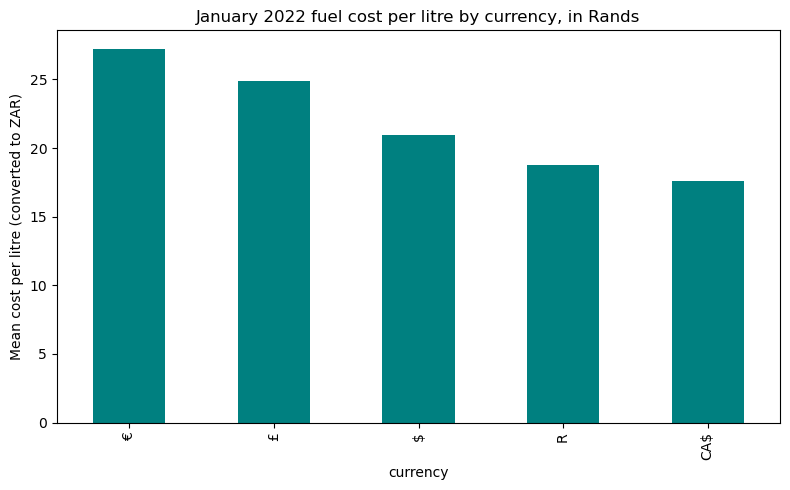

currency
€      27.213396
£      24.851667
$      20.924001
R      18.756498
CA$    17.562784
dtype: float64

In [40]:
CURRENCY_TO_ZAR_JAN2022 = {
    "$": 15.20,    # USD
    "£": 20.60,    # GBP
    "€": 17.20,    # EUR
    "CA$": 12.00,  # CAD
    "AU$": 10.90,  # AUD
    "R": 1.00,     # ZAR itself
    "R$": 2.75,    # BRL
    "RM": 3.65,    # MYR
    "NZ$": 10.05,  # NZD (approx)
    "Rs": 0.204,   # INR (approx)
}

missing_rates = [c for c in top5_currencies if c not in CURRENCY_TO_ZAR_JAN2022]
if missing_rates:
    print(f"WARNING: no Jan-2022 ZAR rate on file for {missing_rates} - "
          f"add these before trusting the plot below.")

jan22 = df42[
    (df42["date_fueled_clean"].dt.year == 2022) &
    (df42["date_fueled_clean"].dt.month == 1)
].copy()
print(f"January 2022 rows in top-5-currency subset: {len(jan22)}")

jan22_cpl = jan22.groupby("currency")["cost_per_litre"].mean().dropna()
jan22_cpl_zar = (jan22_cpl * jan22_cpl.index.map(CURRENCY_TO_ZAR_JAN2022)).dropna()
jan22_cpl_zar = jan22_cpl_zar.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
jan22_cpl_zar.plot(kind="bar", ax=ax, color="teal")
ax.set_ylabel("Mean cost per litre (converted to ZAR)")
ax.set_title("January 2022 fuel cost per litre by currency, in Rands")
plt.tight_layout()
plt.show()

jan22_cpl_zar


### Q4.2.2 - Detecting missed fill-up logs via odometer readings

**Rule used:** for each user, sort their records by `date_fueled_clean` and
compute the odometer distance between consecutive fill-ups
(`odo_diff = odometer_clean[i] - odometer_clean[i-1]`). Compare this to the
`km_driven` recorded for that (later) tank. A single tank cannot plausibly
cover more distance than what was logged for it, so if `odo_diff` is much
larger than the logged `km_driven` (we use a 1.5x threshold), we infer the
user filled up at least once in between without logging it.

In [41]:
odo = df42.dropna(subset=["user_id", "date_fueled_clean", "odometer_clean", "km_driven"]).copy()
odo = odo.sort_values(["user_id", "date_fueled_clean"])

odo["odo_diff"] = odo.groupby("user_id")["odometer_clean"].diff()
odo["gap_ratio"] = odo["odo_diff"] / odo["km_driven"]

# Only consider genuine consecutive-fillup gaps: positive odometer progress,
# and a finite ratio (guards against divide-by-zero when km_driven == 0)
valid_gap = odo["odo_diff"].notna() & (odo["odo_diff"] > 0) & np.isfinite(odo["gap_ratio"])

MISSED_THRESHOLD = 1.5
missed_mask = valid_gap & (odo["gap_ratio"] > MISSED_THRESHOLD)

n_missed = int(missed_mask.sum())
n_checkable = int(valid_gap.sum())
print(f"Checkable consecutive fill-up pairs: {n_checkable}")
print(f"Flagged as likely missed fill-up (odometer gap > {MISSED_THRESHOLD}x logged km_driven): {n_missed}")
print(f"Estimated missed-logging rate: {100 * n_missed / n_checkable:.2f}%")

odo.loc[missed_mask, ["user_id", "date_fueled_clean", "odometer_clean", "odo_diff", "km_driven", "gap_ratio"]].head(10)


Checkable consecutive fill-up pairs: 609599
Flagged as likely missed fill-up (odometer gap > 1.5x logged km_driven): 232932
Estimated missed-logging rate: 38.21%


,user_id,date_fueled_clean,odometer_clean,odo_diff,km_driven,gap_ratio
849849,100002,2012-01-19,76322.0,1322.0,696.966492,1.896791
804491,100002,2012-02-12,78909.0,2176.0,513.571926,4.236992
191924,100002,2012-03-08,82317.0,2947.0,640.325791,4.602345
836687,1000024,2021-03-06,35204.0,1462.0,567.173059,2.577696
378026,1000024,2021-09-26,37456.0,1509.0,666.731907,2.263279
120684,1000031,2020-06-24,186901.0,1249.0,408.774663,3.055473
1091550,1000031,2020-11-08,190441.0,2543.0,434.718415,5.849764
615140,1000031,2020-12-07,191522.0,819.0,423.199214,1.935259
139720,1000050,2021-06-25,248793.0,884.0,277.138049,3.189746
929385,1000050,2021-09-10,249590.0,683.0,172.098097,3.968667


### Q4.2.3 - Average distance (km) per tank, per country

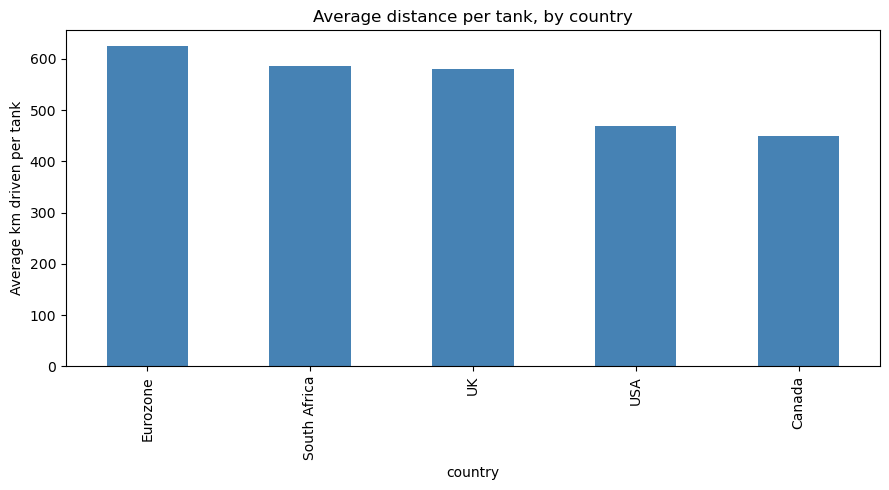

Largest average distance per tank: Eurozone (624.5 km)


country
Eurozone        624.537470
South Africa    585.876008
UK              580.385149
USA             469.099964
Canada          449.603233
Name: km_driven, dtype: float64

In [42]:
avg_km_by_country = df42.groupby("country")["km_driven"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
avg_km_by_country.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Average km driven per tank")
ax.set_title("Average distance per tank, by country")
plt.tight_layout()
plt.show()

print(f"Largest average distance per tank: {avg_km_by_country.idxmax()} "
      f"({avg_km_by_country.max():.1f} km)")
avg_km_by_country


### Q4.2.4 - Do newer vehicles drive further between fill-ups?

We use `vehicle_age` (created by Person B in Section 3: `date_fueled_clean`
year minus `year` parsed from the URL) against `km_driven` per tank,
restricted to `vehicle_age` between 0 and 40 to exclude clearly bad year
values - consistent with Person B's Q3.3 approach.

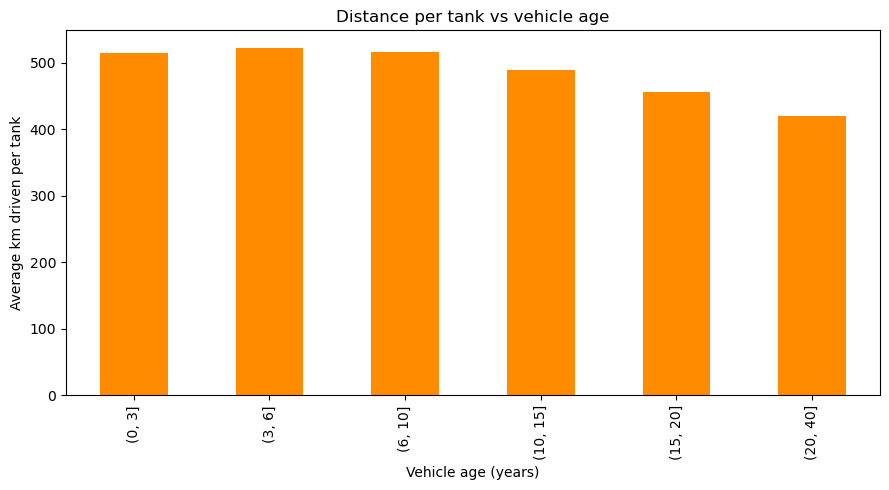

Correlation between vehicle_age and km_driven: -0.026


In [43]:
age_km = df42.dropna(subset=["vehicle_age", "km_driven"])
age_km = age_km[age_km["vehicle_age"].between(0, 40)]

age_bins = pd.cut(age_km["vehicle_age"], bins=[0, 3, 6, 10, 15, 20, 40])
avg_km_by_age = age_km.groupby(age_bins, observed=True)["km_driven"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
avg_km_by_age.plot(kind="bar", ax=ax, color="darkorange")
ax.set_ylabel("Average km driven per tank")
ax.set_xlabel("Vehicle age (years)")
ax.set_title("Distance per tank vs vehicle age")
plt.tight_layout()
plt.show()

corr = age_km["vehicle_age"].corr(age_km["km_driven"])
print(f"Correlation between vehicle_age and km_driven: {corr:.3f}")


### Q4.2.5 - Top 5 most popular vehicles in SA (currency == "R"): fuel efficiency

In [44]:
sa42 = df42[df42["currency"] == "R"].copy()
sa42["make_model"] = sa42["make"].fillna("Unknown") + " " + sa42["model"].fillna("Unknown")

top5_sa_vehicles = sa42["make_model"].value_counts().head(5)
print("Top 5 most popular vehicles in SA (by number of fill-up records):")
print(top5_sa_vehicles)

sa_eff = (
    sa42[sa42["make_model"].isin(top5_sa_vehicles.index)]
    .groupby("make_model")["litres_per_100km"]
    .agg(["mean", "median", "count"])
    .loc[top5_sa_vehicles.index]
)
sa_eff


Top 5 most popular vehicles in SA (by number of fill-up records):
make_model
toyota hilux         1353
mitsubishi pajero    1178
toyota fortuner      1065
suzuki jimny          961
volkswagen amarok     780
Name: count, dtype: int64


,mean,median,count
make_model,,,
toyota hilux,12.338312,11.308388,1134
mitsubishi pajero,13.106261,12.250754,962
toyota fortuner,11.930967,10.940208,901
suzuki jimny,12.047705,8.876018,839
volkswagen amarok,11.204946,10.500646,664


### Q4.2.6 - Most fuel-efficient vehicle in each (top-5) country

To keep this meaningful, we only consider make/model combinations with at
least 5 fill-up records for that currency, and restrict `litres_per_100km` to
a plausible range (3-25 l/100km) before averaging, so a single leftover bad
reading can't crown an unrealistic "winner" - this is the sanity check the
brief calls out explicitly.

In [45]:
PLAUSIBLE_LO, PLAUSIBLE_HI = 3, 25
MIN_RECORDS = 5

eff42 = df42.copy()
eff42["make_model"] = eff42["make"].fillna("Unknown") + " " + eff42["model"].fillna("Unknown")
eff42_plausible = eff42[eff42["litres_per_100km"].between(PLAUSIBLE_LO, PLAUSIBLE_HI)]

most_efficient = {}
for cur in top5_currencies:
    sub = eff42_plausible[eff42_plausible["currency"] == cur]
    stats = sub.groupby("make_model")["litres_per_100km"].agg(["mean", "count"])
    stats = stats[stats["count"] >= MIN_RECORDS]
    if stats.empty:
        most_efficient[cur] = None
        continue
    best = stats["mean"].idxmin()
    most_efficient[cur] = (best, stats.loc[best, "mean"], stats.loc[best, "count"])

for cur, result in most_efficient.items():
    country_name = CURRENCY_TO_COUNTRY.get(cur, cur)
    if result is None:
        print(f"{cur} ({country_name}): no make/model had >= {MIN_RECORDS} plausible records")
    else:
        model_name, val, n = result
        print(f"{cur} ({country_name}): {model_name} - {val:.2f} l/100km (n={n})")


$ (USA): Unknown renault - 3.82 l/100km (n=5)
£ (UK): mercedes-benz a250e - 3.93 l/100km (n=6)
€ (Eurozone): toyota prius_plug-in - 3.70 l/100km (n=5)
CA$ (Canada): toyota prius_prime - 4.07 l/100km (n=39)
R (South Africa): renault kwid - 5.23 l/100km (n=21)


### Q4.2.7 - Fuel efficiency by season, top 5 Canadian vehicles

Canada is in the Northern Hemisphere, so we use the standard meteorological
seasons (Winter: Dec-Feb, Spring: Mar-May, Summer: Jun-Aug, Fall: Sep-Nov)
based on `date_fueled_clean`. We'd expect winter efficiency to be worse than
summer - colder engine/oil, more idling and short trips, winter tyres, and
(in some regions) winter fuel blends.

Top 5 Canadian vehicles: ['mazda 3_sport', 'volkswagen jetta', 'toyota matrix', 'volkswagen golf', 'hyundai accent']


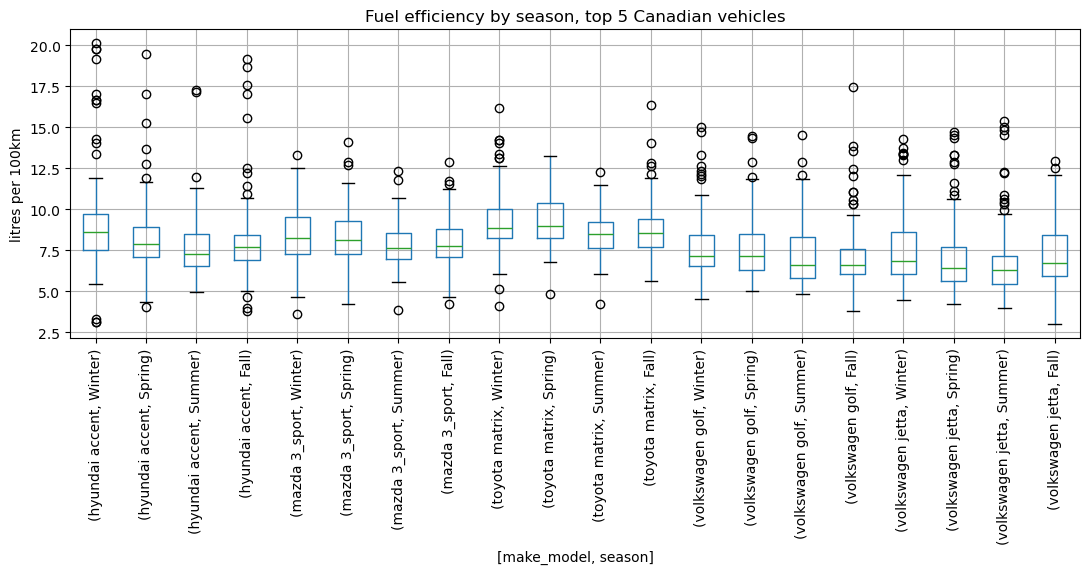

season,Winter,Spring,Summer,Fall
make_model,,,,
hyundai accent,9.095865,8.232452,7.861711,8.050668
mazda 3_sport,8.462663,8.339473,7.828362,7.961087
toyota matrix,9.304307,9.239439,8.474624,8.695613
volkswagen golf,7.725466,7.548080,7.182305,7.134378
volkswagen jetta,7.483018,7.023554,6.708696,7.347671


In [46]:
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Fall"

ca42 = df42[df42["currency"] == "CA$"].copy()
ca42["make_model"] = ca42["make"].fillna("Unknown") + " " + ca42["model"].fillna("Unknown")
ca42["season"] = ca42["date_fueled_clean"].dt.month.map(month_to_season)

top5_ca_vehicles = ca42["make_model"].value_counts().head(5).index.tolist()
print("Top 5 Canadian vehicles:", top5_ca_vehicles)

ca_top5 = ca42[
    ca42["make_model"].isin(top5_ca_vehicles) & ca42["litres_per_100km"].between(3, 25)
].copy()

season_order = ["Winter", "Spring", "Summer", "Fall"]
ca_top5["season"] = pd.Categorical(ca_top5["season"], categories=season_order, ordered=True)

fig, ax = plt.subplots(figsize=(11, 6))
ca_top5.boxplot(column="litres_per_100km", by=["make_model", "season"], ax=ax, rot=90)
ax.set_title("Fuel efficiency by season, top 5 Canadian vehicles")
ax.set_ylabel("litres per 100km")
plt.suptitle("")
plt.tight_layout()
plt.show()

ca_top5.groupby(["make_model", "season"], observed=True)["litres_per_100km"].mean().unstack()


### Q4.2.8 - Correlation between fuel efficiency and other features

We check `litres_per_100km` against the numeric candidates (`km_driven`,
`vehicle_age`, `gallons_clean`, `total_spent_value`) using Pearson
correlation, and against the categorical `model` using a one-way ANOVA
F-statistic (does mean efficiency differ significantly across models?),
following Lecture 4's guidance on numerical-target/categorical-input feature
importance.

litres_per_100km     1.000000
gallons_clean        0.038272
vehicle_age          0.027263
total_spent_value   -0.000205
km_driven           -0.020536
Name: litres_per_100km, dtype: float64


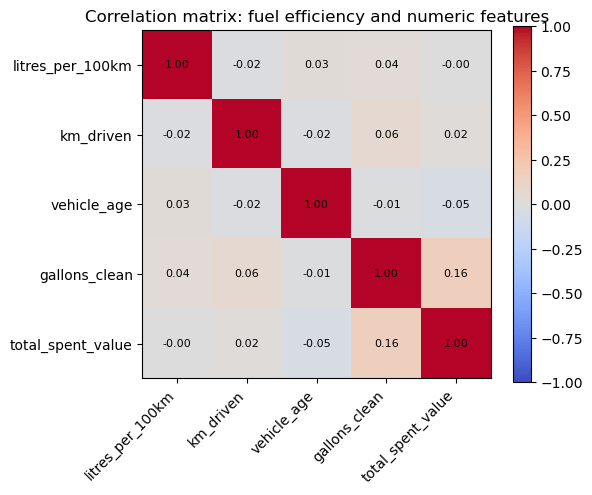


One-way ANOVA, litres_per_100km by model: F=7.98, p=0


In [47]:
from scipy import stats as scipy_stats

corr_cols = ["litres_per_100km", "km_driven", "vehicle_age", "gallons_clean", "total_spent_value"]
corr_df = df42[corr_cols].dropna()
corr_matrix = corr_df.corr()
print(corr_matrix["litres_per_100km"].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation matrix: fuel efficiency and numeric features")
plt.tight_layout()
plt.show()

# Categorical: does litres_per_100km differ by model? (one-way ANOVA)
model_groups = [
    g["litres_per_100km"].dropna().values
    for _, g in df42.dropna(subset=["model", "litres_per_100km"]).groupby("model")
    if len(g) >= 5
]
f_stat, p_val = scipy_stats.f_oneway(*model_groups)
print(f"\nOne-way ANOVA, litres_per_100km by model: F={f_stat:.2f}, p={p_val:.4g}")


### Q4.2.9 - Random Forest feature importances

We fit a Random Forest Regressor to predict `litres_per_100km` from
`km_driven`, `vehicle_age`, `currency`, `make`, and `model` (label-encoded,
following Lecture 4's embedded-methods approach), and compare the resulting
importances against the correlations/ANOVA from Q8.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

rf_df = df42.dropna(
    subset=["litres_per_100km", "km_driven", "vehicle_age", "currency", "make", "model"]
).copy()

le_currency = LabelEncoder()
le_make = LabelEncoder()
le_model = LabelEncoder()
rf_df["currency_enc"] = le_currency.fit_transform(rf_df["currency"])
rf_df["make_enc"] = le_make.fit_transform(rf_df["make"])
rf_df["model_enc"] = le_model.fit_transform(rf_df["model"])

feature_cols = ["km_driven", "vehicle_age", "currency_enc", "make_enc", "model_enc"]
X = rf_df[feature_cols]
y = rf_df["litres_per_100km"]

rf = RandomForestRegressor(n_estimators=250, random_state=42, max_depth=10)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Random Forest feature importances - litres_per_100km")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importances


## 4.3 Fuel Usage in South Africa

"The above dataset" is read as the cleaned, outlier-removed dataset from 4.1
(`df_stage2`), continuing straight from Section 4.1 above (4.2, Person C's
fuel-efficiency section, sits between these in the final merged report but
isn't part of this notebook segment).

In [ ]:
## Q4.3.1 - filter to SA drivers. NOTE: currency must be exactly "R" -
## "R$" is the Brazilian Real and must NOT be included here.
sa = df_stage2[df_stage2["currency"] == "R"].copy()
print("SA rows:", len(sa))


SA rows: 34917


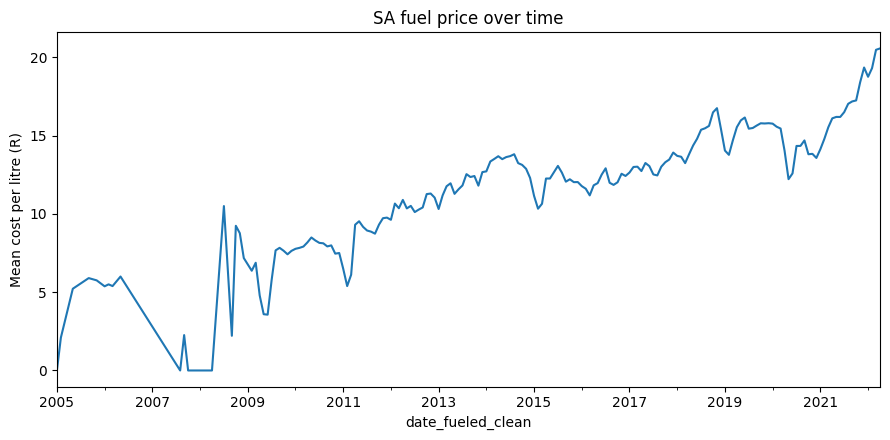

In [ ]:
## Q4.3.2 - fuel prices over time for SA
sa = sa.dropna(subset=["date_fueled_clean", "cost_per_litre"])
monthly_price = sa.groupby(sa["date_fueled_clean"].dt.to_period("M"))["cost_per_litre"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
monthly_price.plot(ax=ax)
ax.set_ylabel("Mean cost per litre (R)")
ax.set_title("SA fuel price over time")
plt.tight_layout()
plt.show()


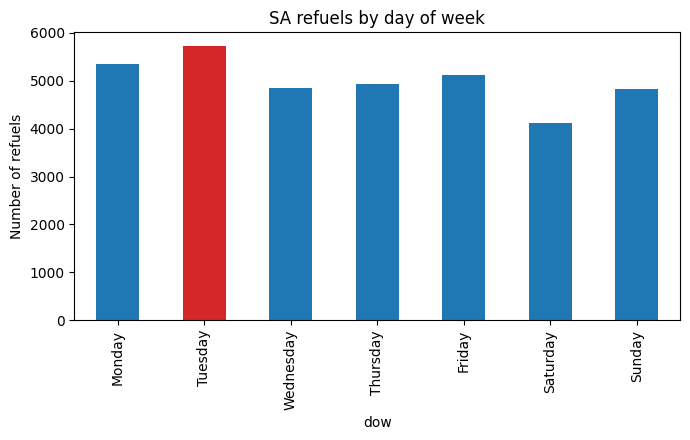

dow
Monday       5345
Tuesday      5724
Wednesday    4858
Thursday     4940
Friday       5117
Saturday     4107
Sunday       4826
Name: count, dtype: int64

In [ ]:
## Q4.3.3 - Tuesday vs other days
sa["dow"] = sa["date_fueled_clean"].dt.day_name()
dow_counts = sa["dow"].value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["tab:red" if d == "Tuesday" else "tab:blue" for d in dow_counts.index]
dow_counts.plot(kind="bar", ax=ax, color=colors)
ax.set_ylabel("Number of refuels")
ax.set_title("SA refuels by day of week")
plt.tight_layout()
plt.show()
dow_counts


In [ ]:
## Q4.3.4 - reduce to 1st Tuesday & 1st Wednesday of each month
sa["month"] = sa["date_fueled_clean"].dt.to_period("M")
sa["day"] = sa["date_fueled_clean"].dt.day

def first_weekday_of_month(period, weekday):
    start = period.start_time
    offset = (weekday - start.weekday()) % 7
    return (start + pd.Timedelta(days=offset)).day

months = sa["month"].unique()
first_tue = {m: first_weekday_of_month(m, 1) for m in months}
first_wed = {m: first_weekday_of_month(m, 2) for m in months}
sa["is_first_tue"] = sa.apply(lambda r: r["day"] == first_tue.get(r["month"]), axis=1)
sa["is_first_wed"] = sa.apply(lambda r: r["day"] == first_wed.get(r["month"]), axis=1)
tue_wed = sa[sa["is_first_tue"] | sa["is_first_wed"]].copy()
print("Rows on first Tue/Wed of month:", len(tue_wed))


Rows on first Tue/Wed of month: 2853


In [ ]:
## Q4.3.5 - price up/down indicator vs previous month
monthly_price_idx = monthly_price.copy()
monthly_price_idx.index = monthly_price_idx.index.to_timestamp()
price_change = monthly_price_idx.diff()
month_direction = price_change.apply(lambda x: "up" if x > 0 else ("down" if x < 0 else "flat"))
month_direction.index = month_direction.index.to_period("M")
tue_wed["price_direction"] = tue_wed["month"].map(month_direction)
n_up_months = (month_direction == "up").sum()
n_down_months = (month_direction == "down").sum()
print(month_direction.value_counts())


cost_per_litre
up      104
down     71
flat      5
Name: count, dtype: int64


In [ ]:
## Q4.3.6 - more refuels on 1st Wednesday when price goes DOWN?
wed_rows = tue_wed[tue_wed["is_first_wed"]]
wed_by_dir = wed_rows.groupby("price_direction").size()
print("Raw counts:\n", wed_by_dir)
print(f"Per-month average -> up: {wed_by_dir.get('up',0)/n_up_months:.2f}, down: {wed_by_dir.get('down',0)/n_down_months:.2f}")


Raw counts:
 price_direction
down    440
flat      1
up      598
dtype: int64
Per-month average -> up: 5.75, down: 6.20


**Discussion (4.3.6):** raw counts alone are misleading if there are more
"up" months than "down" months in the data - the per-month average, printed
above, is the fair comparison.

Raw counts:
 price_direction
down     341
flat       2
up      1471
dtype: int64
Per-month average -> up: 14.14, down: 4.80


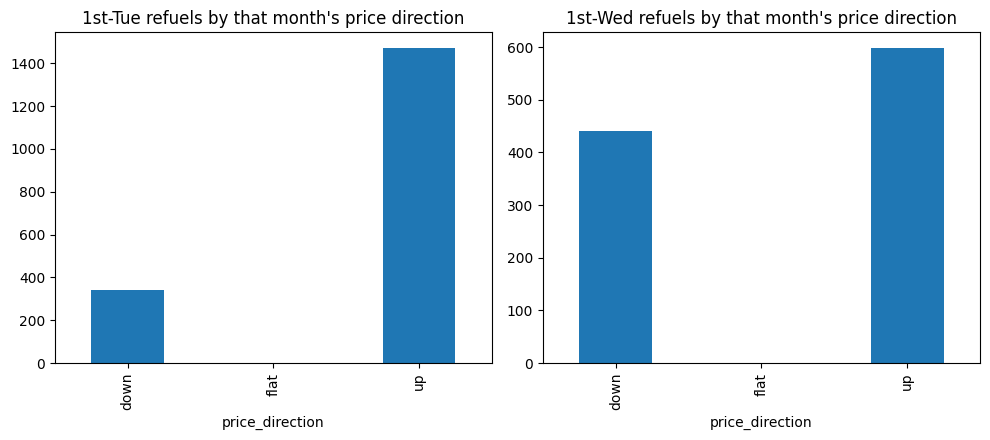

In [ ]:
## Q4.3.7 - more refuels on 1st Tuesday when price goes UP?
tue_rows = tue_wed[tue_wed["is_first_tue"]]
tue_by_dir = tue_rows.groupby("price_direction").size()
print("Raw counts:\n", tue_by_dir)
print(f"Per-month average -> up: {tue_by_dir.get('up',0)/n_up_months:.2f}, down: {tue_by_dir.get('down',0)/n_down_months:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
tue_by_dir.reindex(["down","flat","up"]).plot(kind="bar", ax=axes[0])
axes[0].set_title("1st-Tue refuels by that month's price direction")
wed_by_dir.reindex(["down","flat","up"]).plot(kind="bar", ax=axes[1])
axes[1].set_title("1st-Wed refuels by that month's price direction")
plt.tight_layout()
plt.show()


**Discussion (4.3.7):** compare the per-month average for Tuesday against
the per-month average for Wednesday above - if the Tuesday (price-rise) effect
is much larger than the Wednesday (price-fall) effect, that's a strong
directional confirmation of the brief's hypothesis specifically for the
price-increase case, and only weak/mixed support for the price-decrease
case.